In [15]:
from imports import *
from quick_class import *
import warnings
import fnmatch
from obspy.core.inventory.inventory import read_inventory
# ========================================================================================================================================================
from IPython.display import clear_output
# ================================================================CODE SNIPPETS===========================================================================
# for a in cm._cmap_names_categorical:
#     display(cm.__dict__[a].resampled(4))
# for (Event,Station,Metrics,Comp) in OBS_Generator(catalog,dirs['Py_DataParentFolder']):
#     print(Event)
# for i,(Event,Station,Metrics,Comp) in zip(range(1),OBS_Generator(catalog,dirs['Py_DataParentFolder'])):
#     print(Event)
# # ======================================================================================================================================================
def smooth(d,k=10):return np.convolve(d, np.ones(k) / k, mode='same')
NoiseColors = [mcolors.to_hex(m) for m in [cm.__dict__[e].resampled(30).resampled(6).colors for e in ['devon_categorical']][0]]
# [display(c) for c in [cm.__dict__[e].resampled(70).resampled(5) for e in ['nuuk_categorical','devon_categorical','hawaii_categorical','imola_categorical','lapaz_categorical']]]
# np.array([[mcolors.to_hex(c) for c in r] for r in [cm.__dict__[e].resampled(70).resampled(5).colors for e in ['nuuk_categorical','devon_categorical','hawaii_categorical','imola_categorical','lapaz_categorical']]])
# display(catalog)
print('Stations: ' + str(len(catalog)))
# catalog = catalog.iloc[np.where(catalog.Station=='M08A')[0][0]].to_frame().T
# _ = [print('['+(str(np.round(100*100*i/len(catalog))/100)).zfill(5) + '] ' + n+ '.' +s) for i,s,n in zip(range(len(catalog)),catalog.Station,catalog.Network)]
# _ = [print(s) for s in ('[' + catalog.Network + '] | ' + catalog.Experiment).unique()]

Stations: 101


In [16]:
def write_pickle(file,var):
    import pickle
    with open(str(file), 'wb') as handle:
        pickle.dump(var, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print('Saved to :' + str(file))
def load_pickle(file):
    import pickle
    with open(file, 'rb') as handle:
        b = pickle.load(handle)
    return b

In [17]:
# inv = read_inventory(Path(str(file)).parent / '*_inventory.xml')

# for station in catalog.iloc:
#     pass

In [18]:
# cat = catalog.copy()
# method = 'atacr'
# EvFolder = Path('/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/ATACR_HPS_Comp/_DataArchive/ATaCR_Data/ATaCR_Python/EVENTS')
# reportfolder = Path('/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/ATACR_HPS_Comp/_DataArchive/Analysis/NetworkCoherences')
# # EvFolder_backup = Path('/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/ATACR_HPS_Comp/_DataArchive/Backups/TaperSets/EVENTS_fnotch.taper')
# ttl = ['update','backup']
# tf = 'ZP-21'
# nets = cat.Network.unique()
# coh_report = dict()
# for ni,n in enumerate(nets):
#     file = str(reportfolder / (n + '_' + method.lower() + '_coh.report.pkl'))
#     coh_report = load_pickle(file)
#     icat = cat[cat.Network==n].copy()

[1/12]
[2/12]
[3/12]
[4/12]
[5/12]
[6/12]
[7/12]
[8/12]
[9/12]
[10/12]
[11/12]
[12/12]


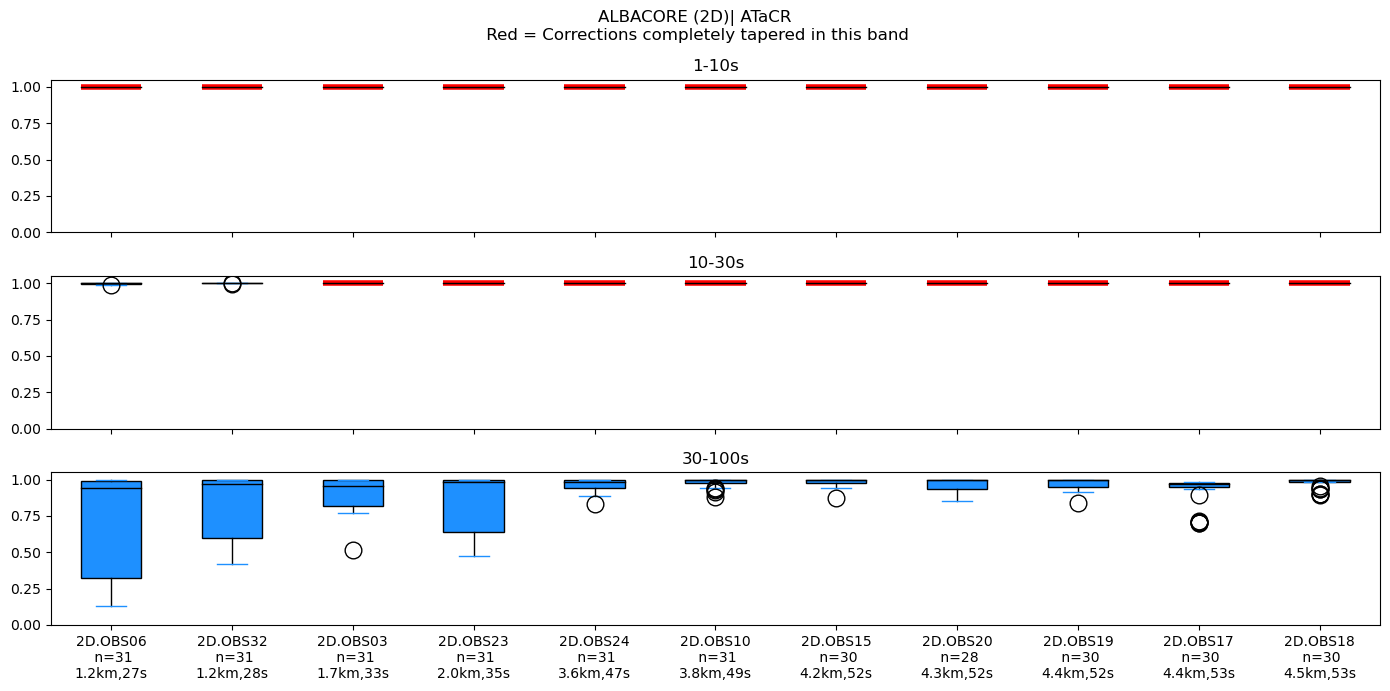

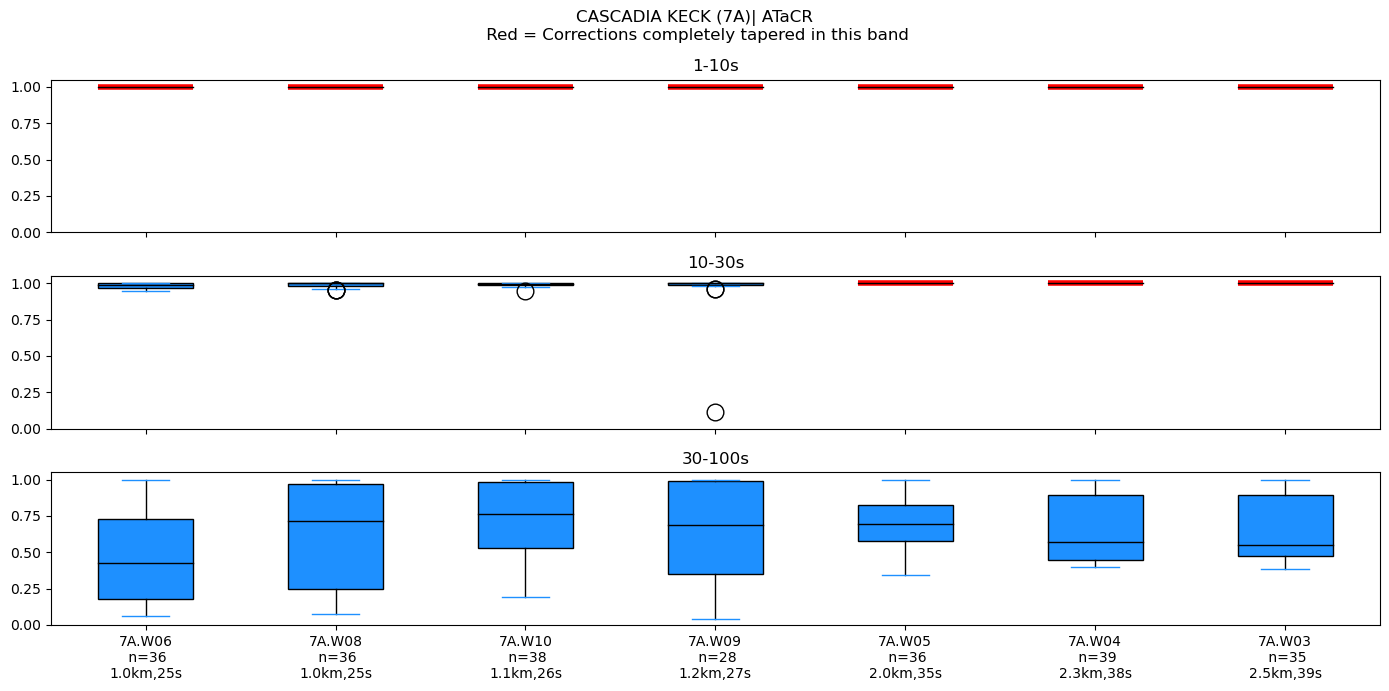

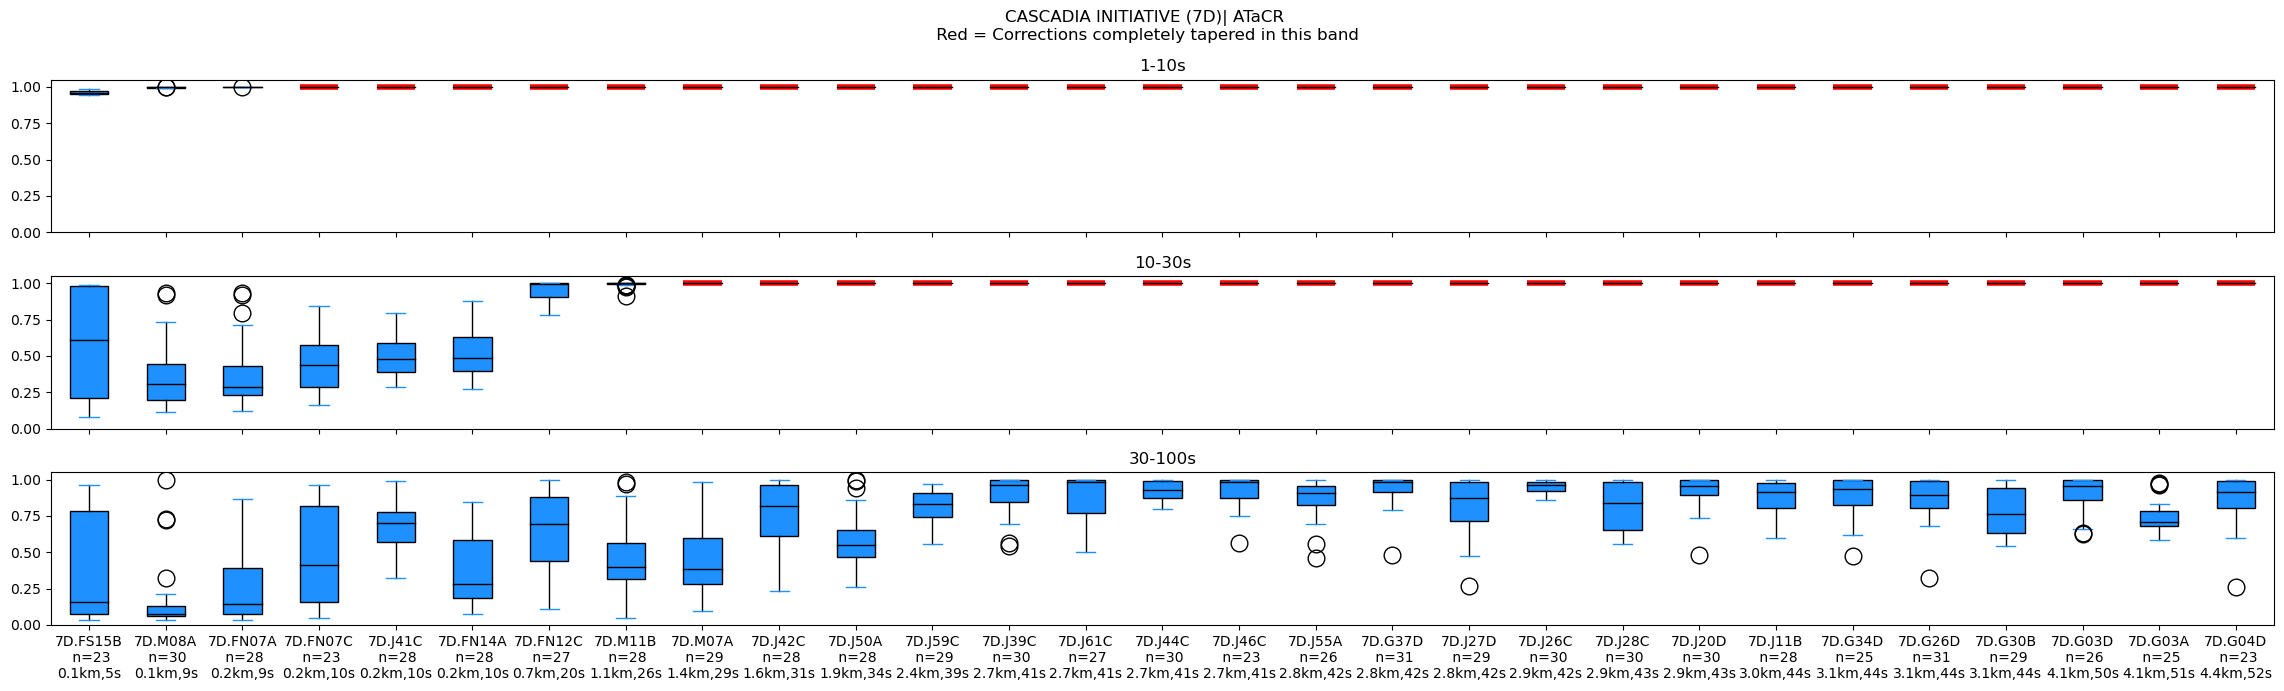

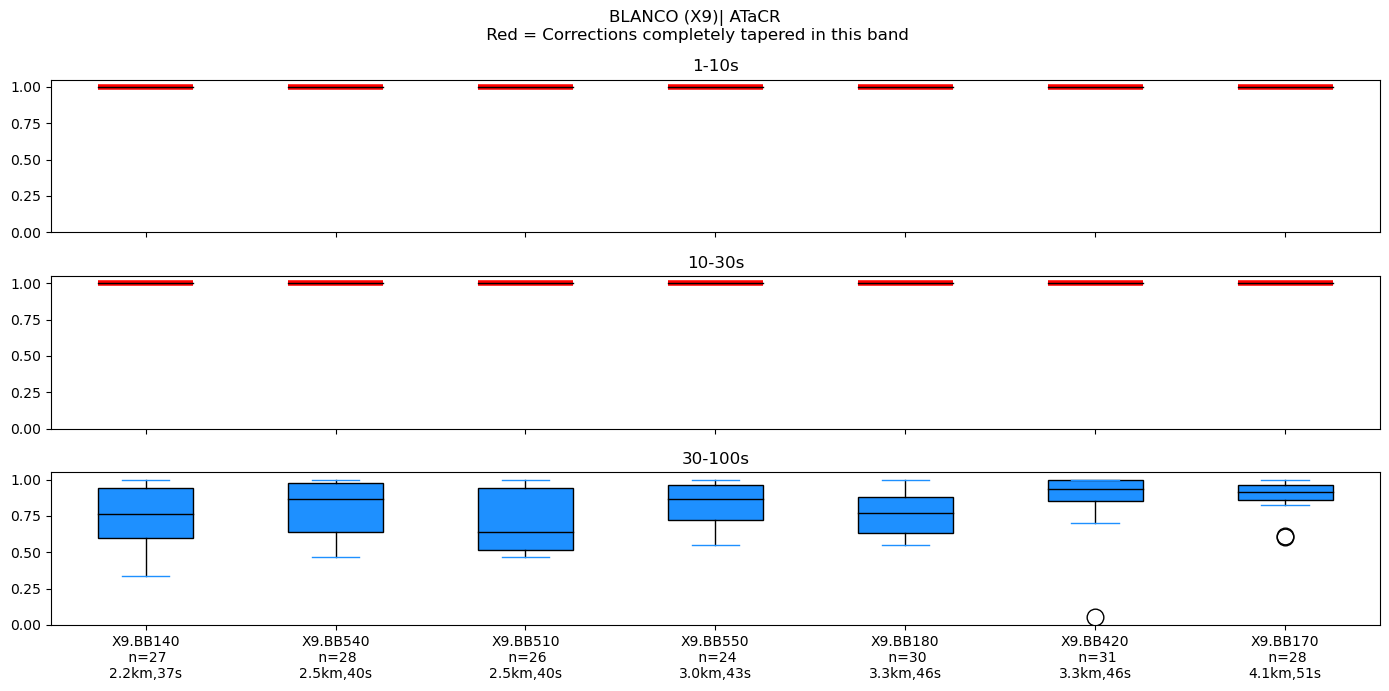

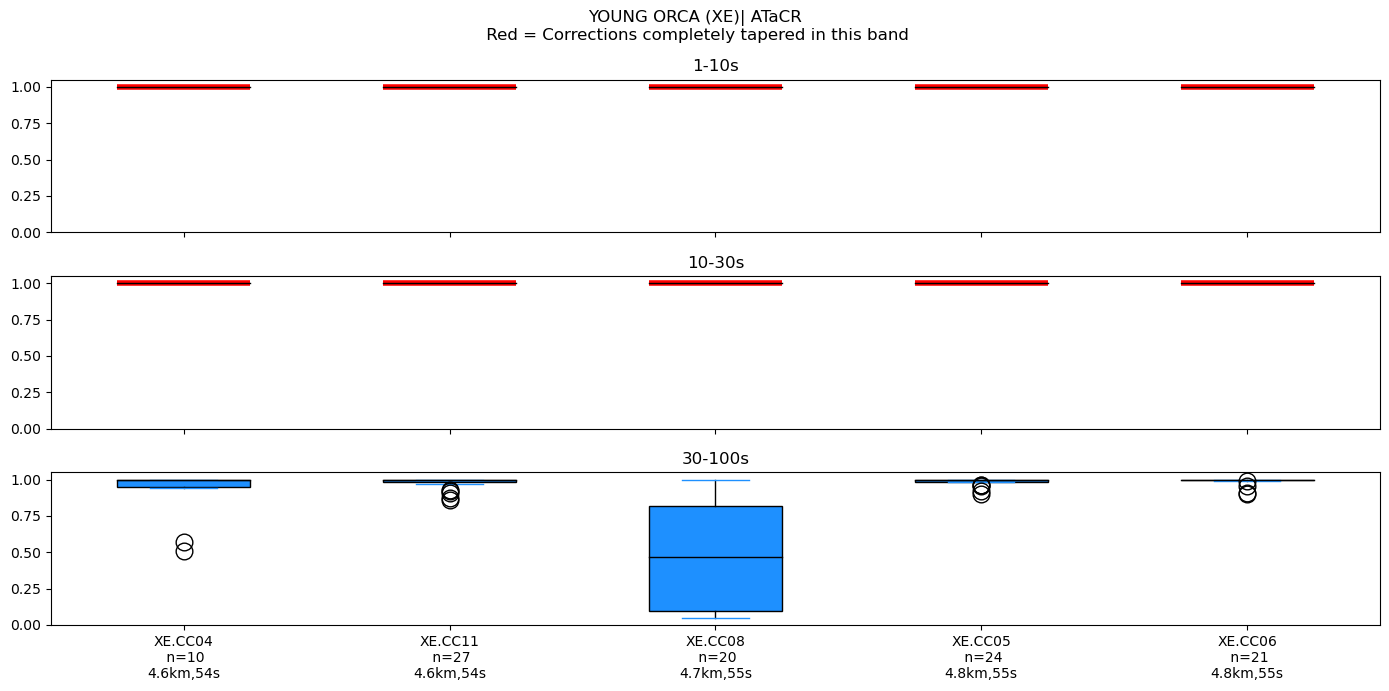

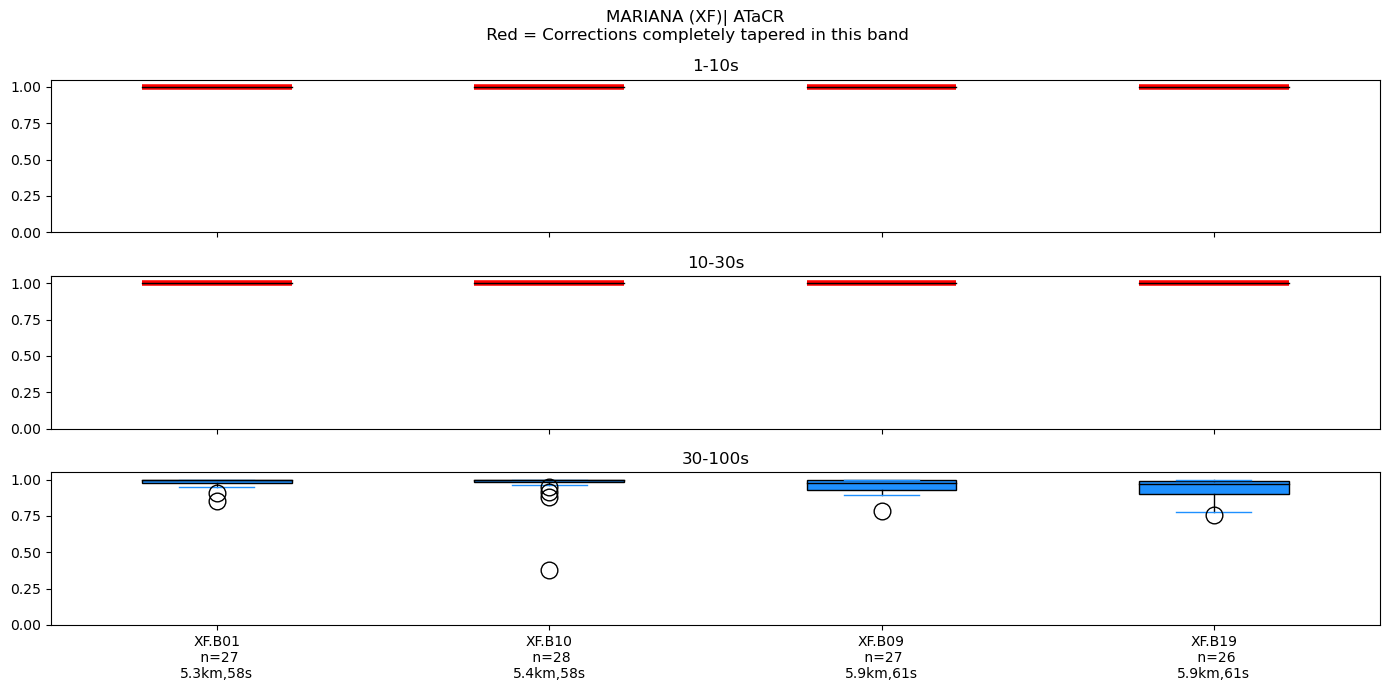

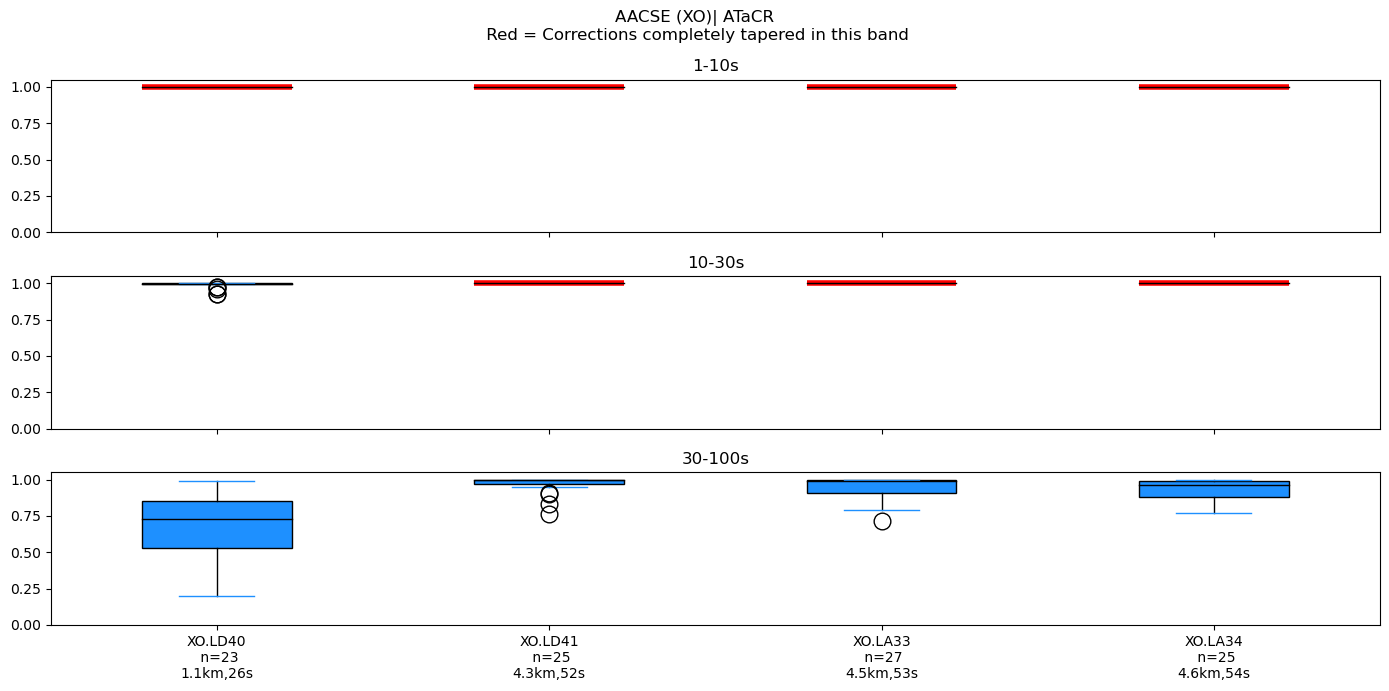

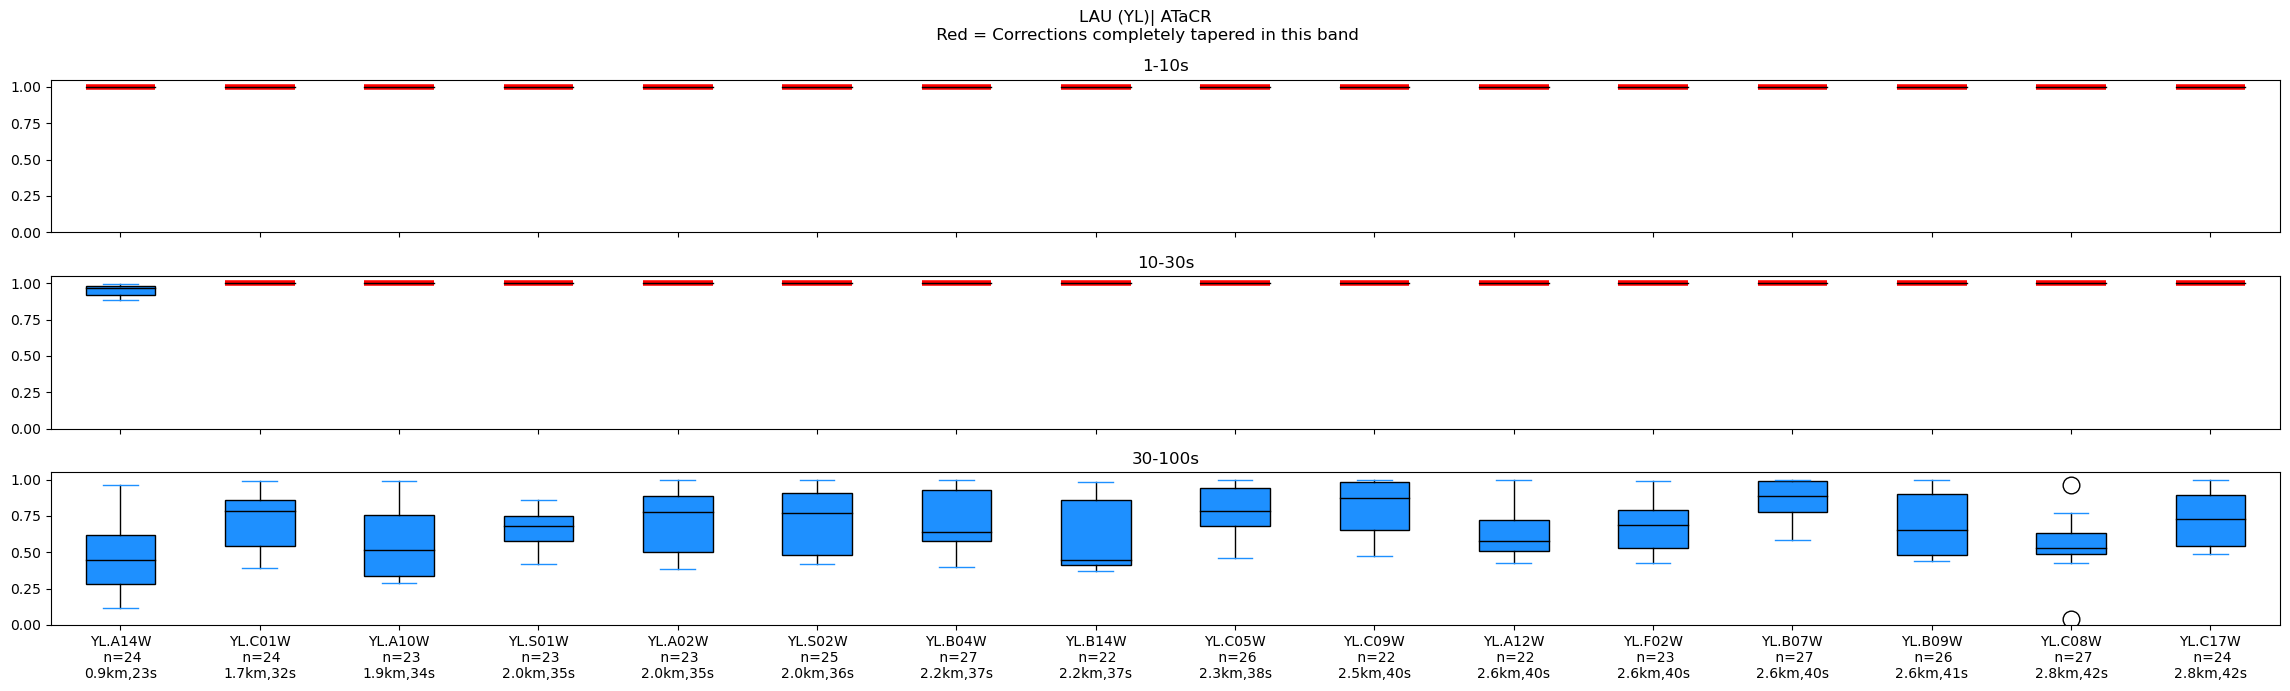

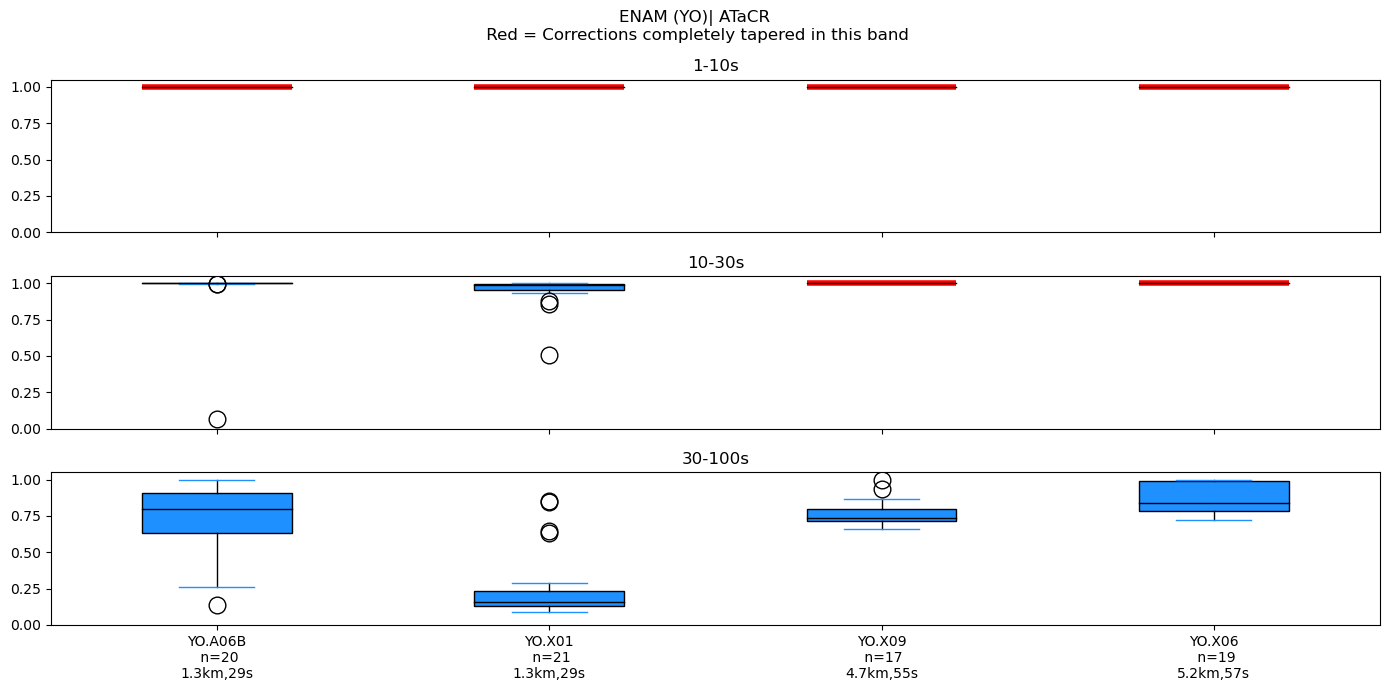

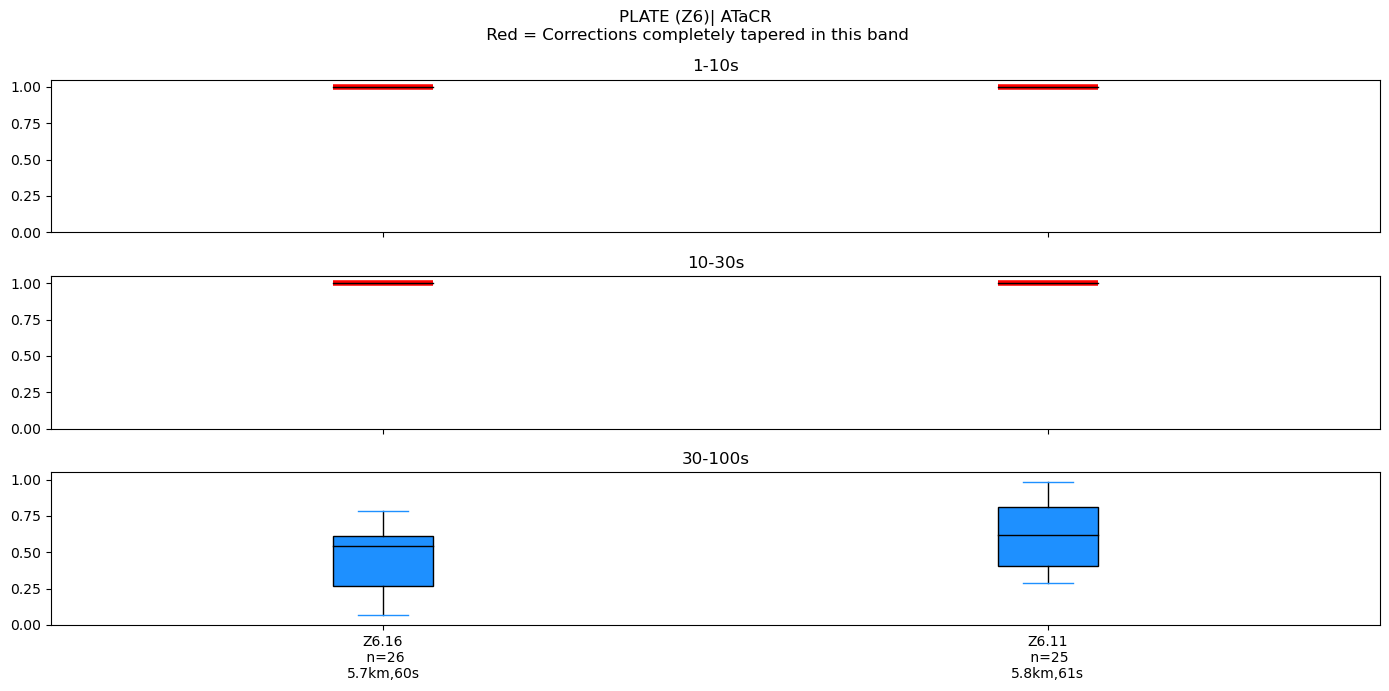

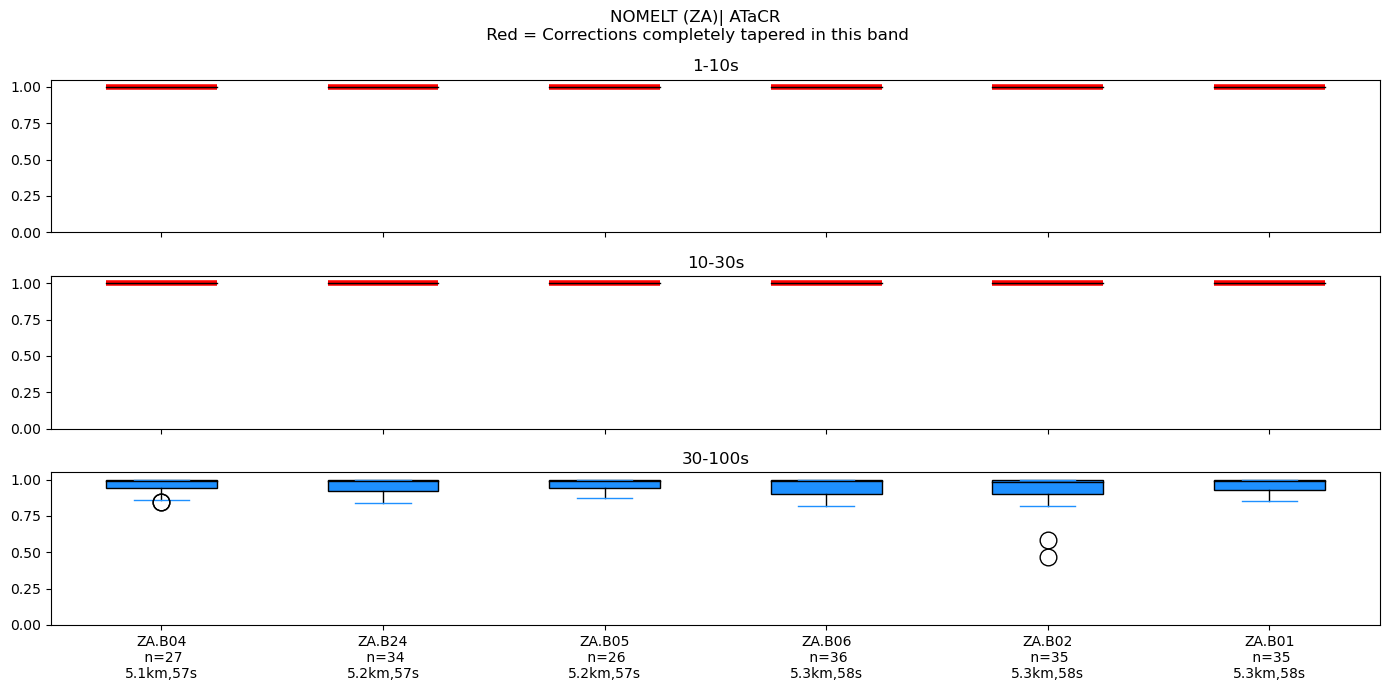

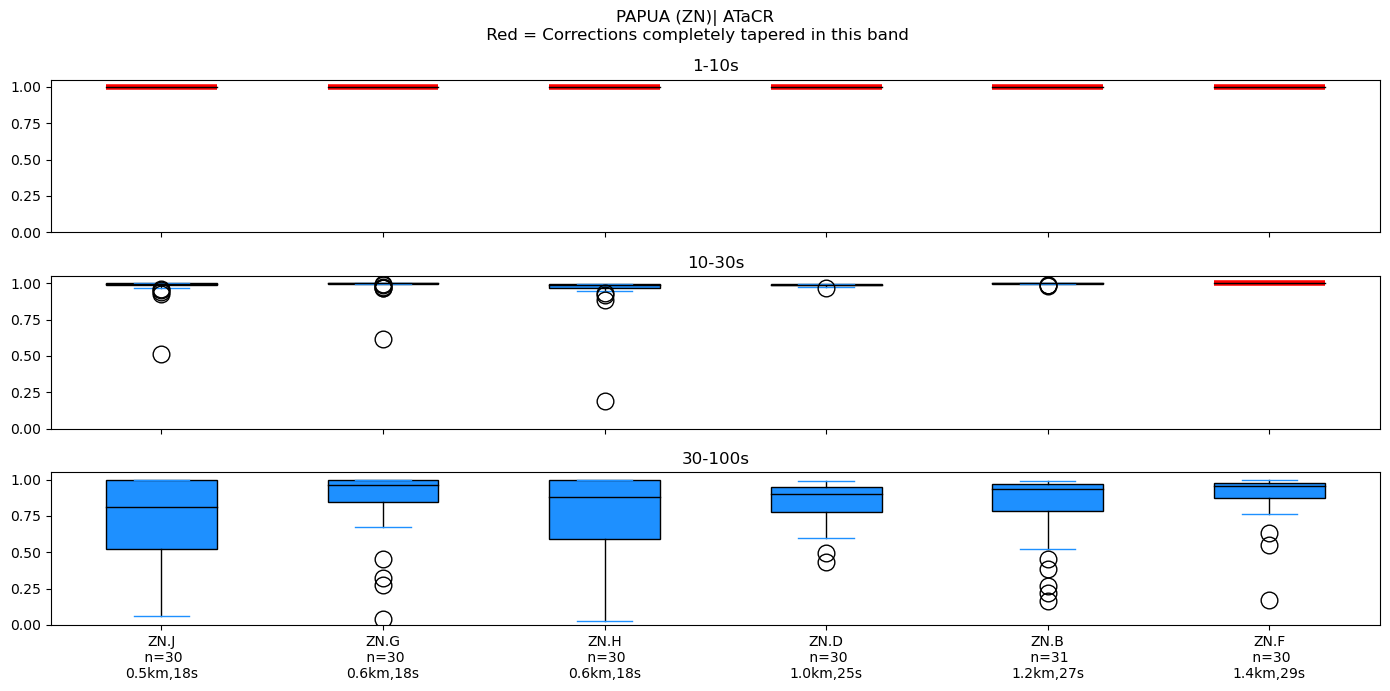

In [22]:
method = 'ATaCR'
# method = 'HPS'

reportfolder = Path('/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/ATACR_HPS_Comp/_DataArchive/Analysis/NetworkCoherences')
bands = ['1-10','10-30','30-100']
cat = catalog.copy()
nets = list(cat.Network.unique())
for ni,n in enumerate(nets):
    file = str(reportfolder / (n + '_' + method.lower() + '_coh.report.pkl'))
    coh_report = load_pickle(file)
    # fig,axes = plt.subplots(nrows=3,ncols=1,squeeze=True,figsize=(30,7),sharey='all')
    icat = cat[cat.Network==n].copy()
    icat = icat.sort_values(by='Water_Depth_m',ascending=True)
    if len(icat)>11:
        fig,axes = plt.subplots(nrows=3,ncols=1,squeeze=True,figsize=(23,7),sharey='all')
    else:
        fig,axes = plt.subplots(nrows=3,ncols=1,squeeze=True,figsize=(14,7),sharey='all')
    depth =[int(s.Water_Depth_m) for s in icat.iloc]
    fn = [round(100/fnotch(s.Water_Depth_m))/100 for s in icat.iloc]
    stanm = [s.StaName for s in icat.iloc]
    m = method.replace('HPS','Noisecut')
    fig.suptitle(icat.iloc[0].Experiment + ' (' + n + ')' + '| '+m+'' + '\n Red = Corrections completely tapered in this band' ,y=0.98)
    print('['+str(ni+1)+'/'+str(len(nets))+']')
    labels = [s +',n=' + '\n[' + str(round(10*(d/1000))/10) + 'km] \nNotch:' + str(int(notch*10)/10) + 's' for s,d,notch in zip(stanm,depth,fn)]
    for axi,(ax,b )in enumerate(zip(axes,bands)):
        yy = []
        fnotch_n = 0
        outside_band = []
        for si,sta in enumerate(icat.iloc):
                notch = round(100/fnotch(sta.Water_Depth_m))/100 
                # print('['+str(ni+1)+'/'+str(len(nets))+']'+'['+str(si+1)+'/'+str(len(icat))+']')
                band_hz = [1/int(a) for a in b.split('-')]
                f = coh_report['f']
                coh = coh_report[sta.StaName]
                ind = (f<band_hz[0]) & (f>=band_hz[1]) #& (f<fnotch(sta.Water_Depth_m))
                if len(np.where(f[ind] < fnotch(sta.Water_Depth_m))[0])==0:
                    fnotch_n+=1
                    outside_band.append(si)
                    coh = coh*0+1
                    # continue
                fband_coh = np.mean(abs(coh)[:,ind],axis=1)
                # fband_coh = np.mean(abs(coh_report[sta.StaName][1])[:,ind],axis=0)
                # xxxxxfband_coh = abs(coh[(f<band_hz[0]) & (f>=band_hz[1])  & (f<fnotch(sta.Water_Depth_m))])
                yy.append(fband_coh)
                nev = coh.shape[0]
                labels[si] = sta.StaName +'\n n='+str(nev)+'\n' + str(round(10*(int(sta.Water_Depth_m)/1000))/10) + 'km,' + str(int(int(notch*10)/10)) + 's' 
        # flierprops = dict(markerfacecolor=color,markeredgecolor=color)
        ax.set_title(b + 's')
        if axi==2:
            bplot = ax.boxplot(yy,patch_artist=True,labels=labels)
        else:
             bplot = ax.boxplot(yy,patch_artist=True,labels=None)
             ax.set_xticklabels([])
        for ii,patch in enumerate(bplot['boxes']):
            if ii in outside_band:
                color='red'
                patch.set_edgecolor(color)
                patch.set_linewidth(4)
            else:
                color='dodgerblue'
            patch.set_facecolor(color)
            bplot['caps'][2*ii]._color = color
            bplot['caps'][2*ii+1]._color = color
            bplot['fliers'][ii]._color = color
            bplot['fliers'][ii]._markersize = 12
            if ii not in outside_band:
                bplot['fliers'][ii]._markeredgecolor = 'k'
                bplot['fliers'][ii]._markersize = 12
            else:
                bplot['fliers'][ii]._markeredgecolor = color
                bplot['fliers'][ii]._markerfacecolor = color
                bplot['whiskers'][2*ii]._color = color
                bplot['whiskers'][2*ii+1]._color = color
            bplot['medians'][ii]._color = 'k'
        ax.set_ylim(0,1.05)
    plt.tight_layout()
    figfold = Path('/Users/charlesh/Documents/Codes/OBS_Methods/NOISE/ATACR_HPS_Comp/RunningNotebooks/znb_images/coh_reports')
    figfold.mkdir(parents=True,exist_ok=True)
    figfile = figfold / (icat.iloc[0].Experiment + '.' + n + '.' + method.lower() + '.png')
    save_tight(figfile,dpi = 600)
    # jlk = jkl

In [ ]:
bplot = ax.boxplot(fruit_weights,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)  # will be used to label x-ticks

# fill with colors
for ii,patch in enumerate(bplot['boxes']):
    if ii in outside_band:
        color='tomato'
    else:
        color='dodgerblue'
    patch.set_facecolor(color)

In [ ]:
def plot_spec_coh_adm_ph(Metrics):
    pairs = ['ZP']
    meters = ['psd','Coherence','Admittance','Phase']
    fig, axes = plt.subplots(nrows=4, ncols=1,figsize=(8,10),layout='constrained',squeeze=False,sharey='row',sharex='all')
    axes = axes.reshape(-1)
    stam = Metrics['ATaCR'].traces[0].stats.network + '.' + Metrics['ATaCR'].traces[0].stats.station
    label = Metrics['ATaCR'].traces.select(channel='*Z')[0].stats.location
    Pre = Metrics['Raw']
    Post = Metrics['ATaCR']
    Noise = Metrics['Noise']
    fn = fnotch(abs(Post.traces[0].stats.sac.stel*1000))
    tstamp = Pre.traces[0].stats.starttime.strftime('%Y.%j.%H.%M')
    for pi,(ax,m) in enumerate(zip(axes,meters)):
        if m=='psd':
            p = 'Z'
        else:
            p = pairs[0]
        evf,prey = Pre.__getattribute__(m)(p)
        evf,posty = Post.__getattribute__(m)(p)
        if m=='psd':
            noisef,noisey = Noise.f,Noise.StaNoise.power.__dict__['cZZ']
        else:
            noisef,noisey = Noise.__getattribute__(m)(p)
        noisey = noisey[noisef>0]
        noisef = noisef[noisef>0]
        if m=='psd':
            noisey = 10*np.log10(noisey)
            prey = 10*np.log10(prey)
            posty = 10*np.log10(posty)
        ax.scatter(noisef,noisey,s=0.5,c='gray',label='Noise')
        if pi==0:
            lbl = stam + ' | ' + label + ' ' + tstamp + ' | '
        else:
            lbl = ''
        ax.set_xlabel('Frequency')
        ax.set_ylabel(m.replace('psd','Power Density'))
        ax.set_title(lbl + p + '-' + m.replace('psd','PSD'),fontweight='bold')
        ax.scatter(evf,prey,c='k',label='PRE',marker='o',s=1)
        ax.scatter(evf,posty,c='m',label='POST',marker='o',s=0.5)
        ax.axvline(fn,linewidth=0.2,color='k')
        if pi==0:
            ax.text(fn*1.05,0.99*min(ax.get_ylim()),'Fn:' + str(round(1/fn*100)/100) + 's',alpha=0.4)
            ax.set_xscale('log')
            ax.set_xlim(evf[1],evf[-1])
            ax.legend(markerscale=10,ncols=len(meters))
    plt.tight_layout()
    return fig

In [ ]:
g

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++ CONSTRUCTOR AREA ++++++++++++++++++++++++++++++
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
methods = ['PostATACR']
atacrdatafolder = archive / 'ATaCR_Data' / 'ATaCR_Python'
for correction_method in methods:
    coh_comp = correction_method.replace('PostHPS','HPS').replace('PostATACR','ATaCR')
    if correction_method=='PostHPS':
      return_hps = True
    else:
      return_hps = False
    OutFolder = Path(plotfolder)
    SubFolders = Path('EventRecords') / correction_method / 'coherence'
    OutFolder = OutFolder / SubFolders
    OutFolder.mkdir(parents=True,exist_ok=True)
    for station in catalog.iloc:
      stations = [station.Station]
      networks = [station.Network]
      events = station.Events
      for i,(net,sta) in enumerate(zip(networks,stations)):
        Metrics = []
        for evi,event in enumerate(events):
          depth = round(station.Metadata[evi].origins[0].depth/1000)
          mag = station.Metadata[evi].magnitudes[0].mag
          File = '.'.join([net,sta]) + '.m' + str(mag) + '.z' + str(depth) + 'km' + '.' + event + '.' + correction_method.replace('Post','') + '_SPECCOHPHADM.png'
          title = File.replace('_',' | ').replace('z','z: ').replace('m','mag: m')
          print('[' + str(evi) + '/' + str(len(events)) + '] ' + File)
          post_record = Stream()
          pre_record = Stream()
          M,Comp = get_metrics_comp(net,sta,atacrdatafolder,event,return_hps=return_hps,events_folder='EVENTS')
          # M['Noise'] = get_Noise(atacrdatafolder,net,sta,'sta')['Noise']
          Metrics.append(M.copy())
          fig = plot_spec_coh_adm_ph(M)
          save_tight(str(plotfolder / 'MeetingFigs' / 'SPECCOHPHADM' / File),fig,dpi=600)


In [ ]:
bplot['boxes'][0]._edgecolor